# Fitoplancton reconvierte progestogenos a su forma activa

> El cuerpo humano lleva décadas neutralizando los anticonceptivos antes de excretarlos. El agua llega al río. Y resulta que el fitoplancton hace lo contrario: los reactiva.

**Paper:** *Chemoproteomics reveals global occurrence of a phytoplankton lyase capable of reconverting progestogens* · Nature Water · 2025

**DOI:** [10.1038/s44221-026-00646-5](https://doi.org/10.1038/s44221-026-00646-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-19-fitoplancton-reconvierte-progestogenos/notebook.ipynb)

## Qué pasa

El **acetato de noretindrona (NEA)** es un progestógeno sintético: la versión "modificada" que llevan muchas pastillas anticonceptivas. Lo de modificar el compuesto no es estético — el acetato hace que la molécula sea más estable y se absorba mejor.

Pero hay otra ruta. El equipo cultivó **18 especies de fitoplancton** —de agua dulce y marina, escogidas para representar grupos evolutivamente distantes— y midió qué pasaba cuando entraba NEA al cultivo. Todas, sin excepción, hacían lo mismo: le arrancaban el acetato.

El producto es noretindrona, un neuroesteroide **más potente** que el NEA original.

Y luego vino la pregunta grande: ¿esto pasa solo en el laboratorio, o el gen responsable está repartido por los océanos? Para responderla usaron bases metagenómicas globales: **135 MAGs** (genomas reconstruidos de fitoplancton) en **11 océanos**, más **29.709 genomas procariotas** con la misma enzima.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_ESPECIES_LAB = 18           # Especies de fitoplancton cultivadas (experimental)
N_MAGS = 135                  # MAGs eukariotos con el gen (observacional global)
N_PROCARIOTAS = 29709         # Genomas procariotas con el gen
N_OCEANOS = 11                # Océanos donde se detectó

FUENTE = 'Fuente: Mu et al. (2025), Nature Water | Datos: Figshare 10.6084/m9.figshare.30518138'
COLOR_DATOS = '#2563EB'       # Azul CaM
COLOR_ALERTA = '#DC2626'      # Rojo
COLOR_SECUNDARIO = '#059669'  # Emerald
COLOR_REFERENCIA = '#D97706'  # Amber
COLOR_CONTEXTO = '#BBBBBB'    # Gris

# ── Imports y estilo ──
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# ── Carga de datos ──
mags = pd.read_csv('datos/fitoplancton_mags.csv')
por_oceano = pd.read_csv('datos/fitoplancton_por_oceano.csv')
por_reino = pd.read_csv('datos/fitoplancton_por_reino.csv')
por_phylum = pd.read_csv('datos/fitoplancton_por_phylum.csv')
proc_phylum = pd.read_csv('datos/procariotas_con_lyase_por_phylum.csv')
proc_cult = pd.read_csv('datos/procariotas_culturabilidad.csv')

print(f'Fitoplancton: {len(mags)} MAGs en {por_oceano.shape[0]} océanos, {por_phylum.shape[0]} phyla')
print(f'Procariotas: {proc_phylum["n_genomas"].sum():,} genomas en {proc_phylum.shape[0]} phyla'.replace(',', '.'))
print(f'Reinos eukariotos: {dict(zip(por_reino["reino"], por_reino["n_mags"]))}')

Fitoplancton: 135 MAGs en 11 océanos, 10 phyla
Procariotas: 29.709 genomas en 140 phyla
Reinos eukariotos: {'Chromista': 67, 'Plantae': 50, 'Protozoa': 17, 'Animalia': 1}


## El reparto de quién carga el gen

Si el experimento fuera anecdótico —"unas pocas algas raras lo hacen"— la historia se quedaría en lab. Lo que el equipo encontró es otra cosa.

Aquí está.

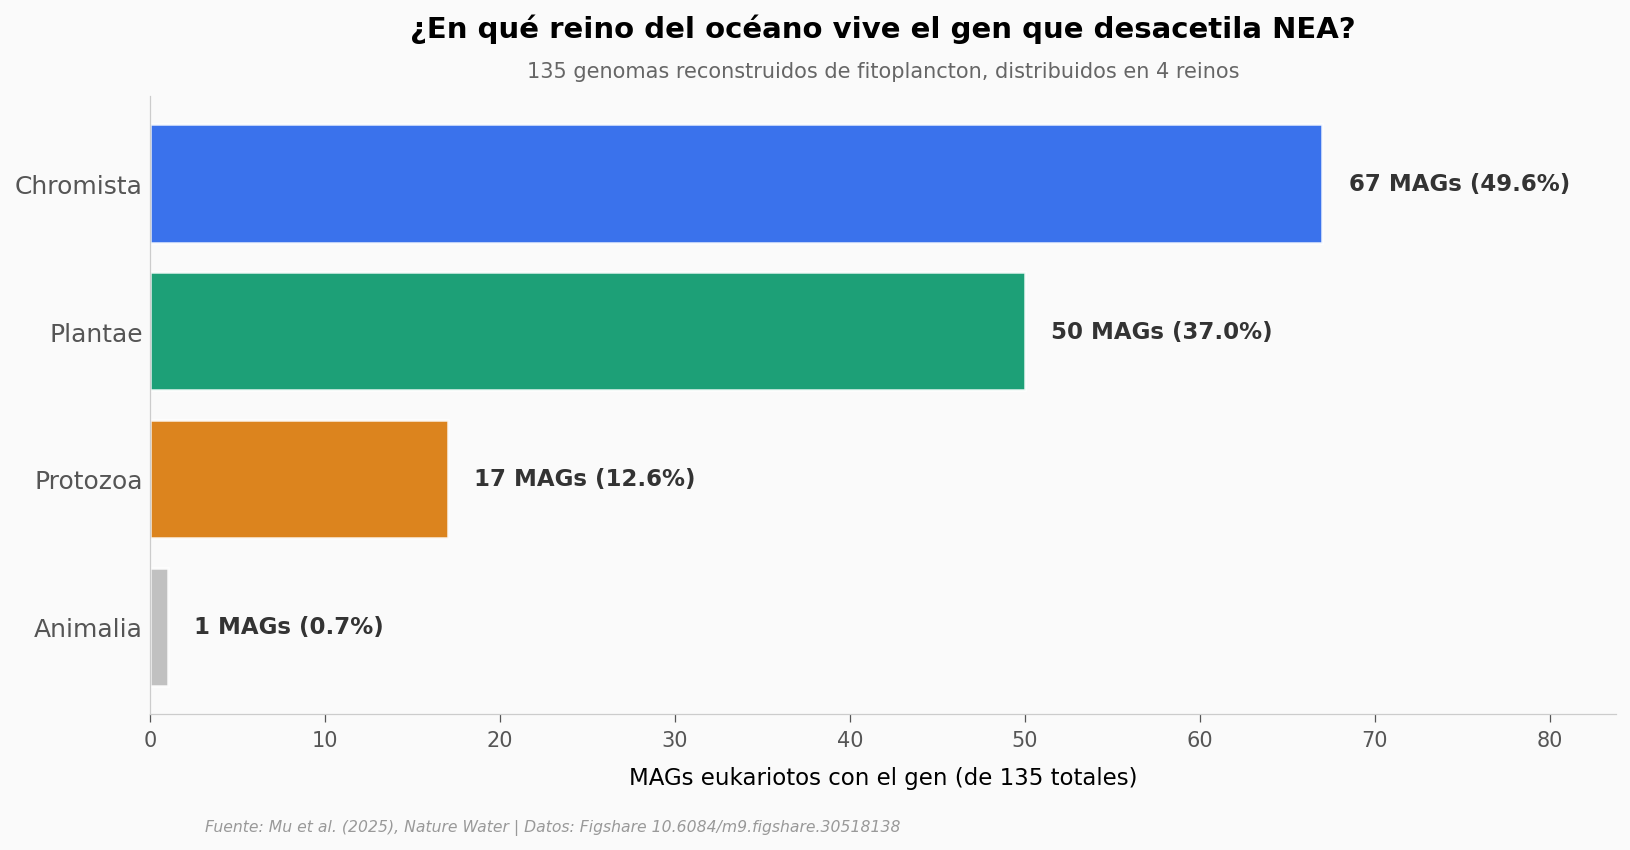

In [2]:
# Gráfica 1: Distribución del gen por reino eukarioto
fig, ax = plt.subplots(figsize=(11, 5.5))

orden = por_reino.sort_values('n_mags', ascending=True)
colores = [COLOR_CONTEXTO, COLOR_REFERENCIA, COLOR_SECUNDARIO, COLOR_DATOS]
y_pos = np.arange(len(orden))

bars = ax.barh(y_pos, orden['n_mags'], color=colores, alpha=0.9,
               edgecolor='white', linewidth=1.2)

for bar, n, reino in zip(bars, orden['n_mags'], orden['reino']):
    pct = 100 * n / orden['n_mags'].sum()
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{int(n)} MAGs ({pct:.1f}%)',
            va='center', fontsize=11, fontweight='bold', color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(orden['reino'], fontsize=12)
ax.set_xlabel('MAGs eukariotos con el gen (de 135 totales)', fontsize=11)
ax.set_title('¿En qué reino del océano vive el gen que desacetila NEA?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '135 genomas reconstruidos de fitoplancton, distribuidos en 4 reinos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, orden['n_mags'].max() * 1.25)
ax.grid(axis='y', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_distribucion_reinos.png', dpi=200, bbox_inches='tight')
plt.show()

**Casi nueve de cada diez MAGs caen en dos reinos:** *Chromista* (donde están las haptofitas y los dinoflagelados) y *Plantae* (donde están las algas verdes). Esos dos grupos no son hermanos cercanos — divergieron hace cientos de millones de años. Que ambos carguen la misma enzima sugiere que esto no es un truco de un grupo evolutivo pequeño (un clade), sino algo extendido en la base del fitoplancton oceánico.

El reino *Animalia* aparece con un solo MAG. Es coherente: este árbol es de fitoplancton, no de animales — la presencia testimonial es ruido esperable de la taxonomía.

## Bajemos a phylum

El reino es una mirada gruesa. Si bajamos un nivel —al phylum, que es donde la diversidad biológica del fitoplancton vive— el patrón se vuelve más concreto. ¿Quiénes son, en lenguaje no taxonómico?

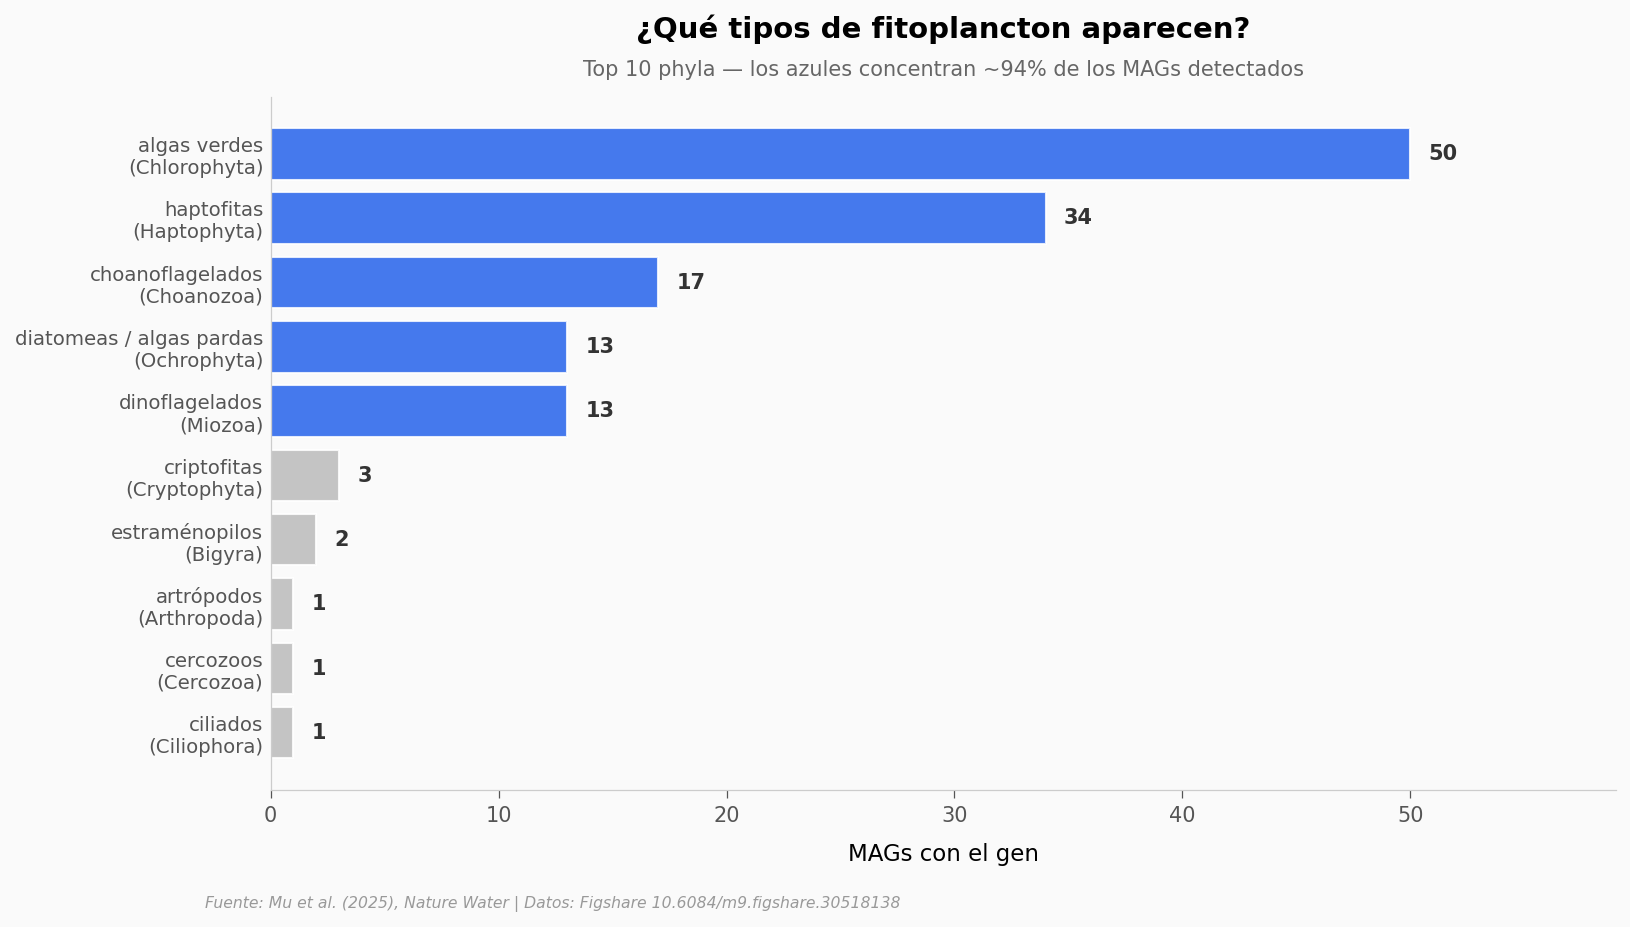

In [3]:
# Gráfica 2: Top phyla con nombres comunes
nombres_comunes = {
    'Chlorophyta': 'algas verdes',
    'Haptophyta': 'haptofitas',
    'Choanozoa': 'choanoflagelados',
    'Miozoa': 'dinoflagelados',
    'Ochrophyta': 'diatomeas / algas pardas',
    'Cryptophyta': 'criptofitas',
    'Cercozoa': 'cercozoos',
    'Bigyra': 'estraménopilos',
    'Ciliophora': 'ciliados',
    'Arthropoda': 'artrópodos',
}

orden = por_phylum.sort_values('n_mags', ascending=True).copy()
orden['etiqueta'] = orden['phylum'].map(lambda p: f"{nombres_comunes.get(p, '')}\n({p})")

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(orden))
colores = [COLOR_DATOS if v >= 13 else COLOR_CONTEXTO for v in orden['n_mags']]
bars = ax.barh(y_pos, orden['n_mags'], color=colores, alpha=0.85,
               edgecolor='white', linewidth=1.0)

for bar, n in zip(bars, orden['n_mags']):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f'{int(n)}', va='center', fontsize=10, fontweight='bold', color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(orden['etiqueta'], fontsize=9.5)
ax.set_xlabel('MAGs con el gen', fontsize=11)
ax.set_title('¿Qué tipos de fitoplancton aparecen?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Top 10 phyla — los azules concentran ~94% de los MAGs detectados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, orden['n_mags'].max() * 1.18)
ax.grid(axis='y', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_phyla_top.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Dónde lo encontraron?

El siguiente paso natural: si el gen está en grupos tan diversos, ¿está repartido por todo el océano o concentrado en unas zonas? Los 135 MAGs vienen de **Tara Oceans**, una de las campañas de muestreo marino más ambiciosas que existen — y agruparlos por cuenca oceánica da una pista del alcance geográfico.

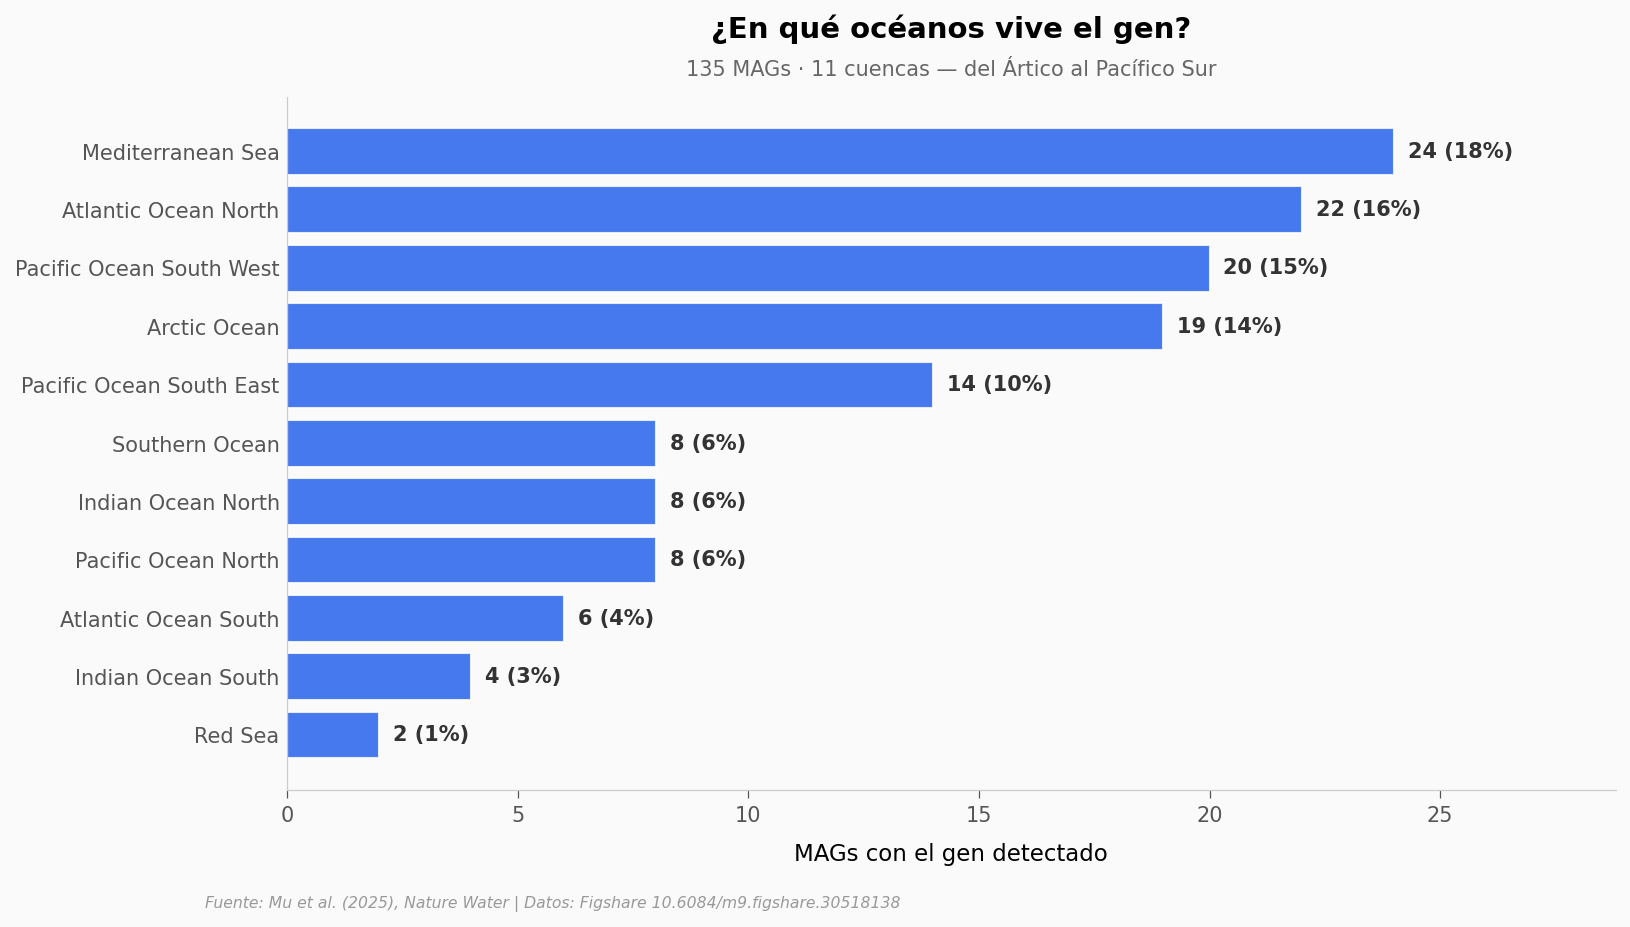

In [4]:
# Gráfica 3: Distribución por océano
orden = por_oceano.sort_values('n_mags', ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(orden))

# Color por hemisferio aproximado — solo para dar variación visual
colores = [COLOR_DATOS] * len(orden)
bars = ax.barh(y_pos, orden['n_mags'], color=colores, alpha=0.85,
               edgecolor='white', linewidth=1.0)

for bar, n in zip(bars, orden['n_mags']):
    pct = 100 * n / orden['n_mags'].sum()
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{int(n)} ({pct:.0f}%)',
            va='center', fontsize=10, fontweight='bold', color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(orden['oceano'], fontsize=10)
ax.set_xlabel('MAGs con el gen detectado', fontsize=11)
ax.set_title('¿En qué océanos vive el gen?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{int(orden["n_mags"].sum())} MAGs · 11 cuencas — del Ártico al Pacífico Sur',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, orden['n_mags'].max() * 1.2)
ax.grid(axis='y', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_oceanos.png', dpi=200, bbox_inches='tight')
plt.show()

**Once cuencas, ningún punto ciego.** El gen aparece desde el Ártico hasta el Pacífico Sur, con el Mediterráneo y el Atlántico Norte concentrando las cifras más altas. Una nota importante: esto refleja también dónde Tara Oceans muestreó más densamente, no solo dónde el gen abunda más. La conclusión defendible es la cualitativa — **el gen no es regional, está en cuencas de todo el planeta**.

> Y un freno conceptual obligado: **detectar el gen no es lo mismo que verlo activo**. Que un MAG cargue la enzima en su genoma no implica que la esté transcribiendo o que esté desacetilando NEA en el agua donde vive. El paper sí muestra que el gen se transcribe en metatranscriptomas globales (lecturas de ARN tomadas directamente del agua de mar), pero la actividad cuantitativa *in situ* —cuánto NEA se reconvierte por mililitro de agua de océano— sigue sin medirse directamente.

## ¿Qué tan raro es esto fuera del fitoplancton?

Hasta ahora hablamos de 135 MAGs eukariotos. Pero el mismo gen aparece en **29.709 genomas de procariotas** (bacterias y arqueas). Eso amplía el problema: la enzima no es exclusiva del fitoplancton — es de un linaje enzimático con alcance mucho mayor.

Veámoslo contra el universo que cubre.

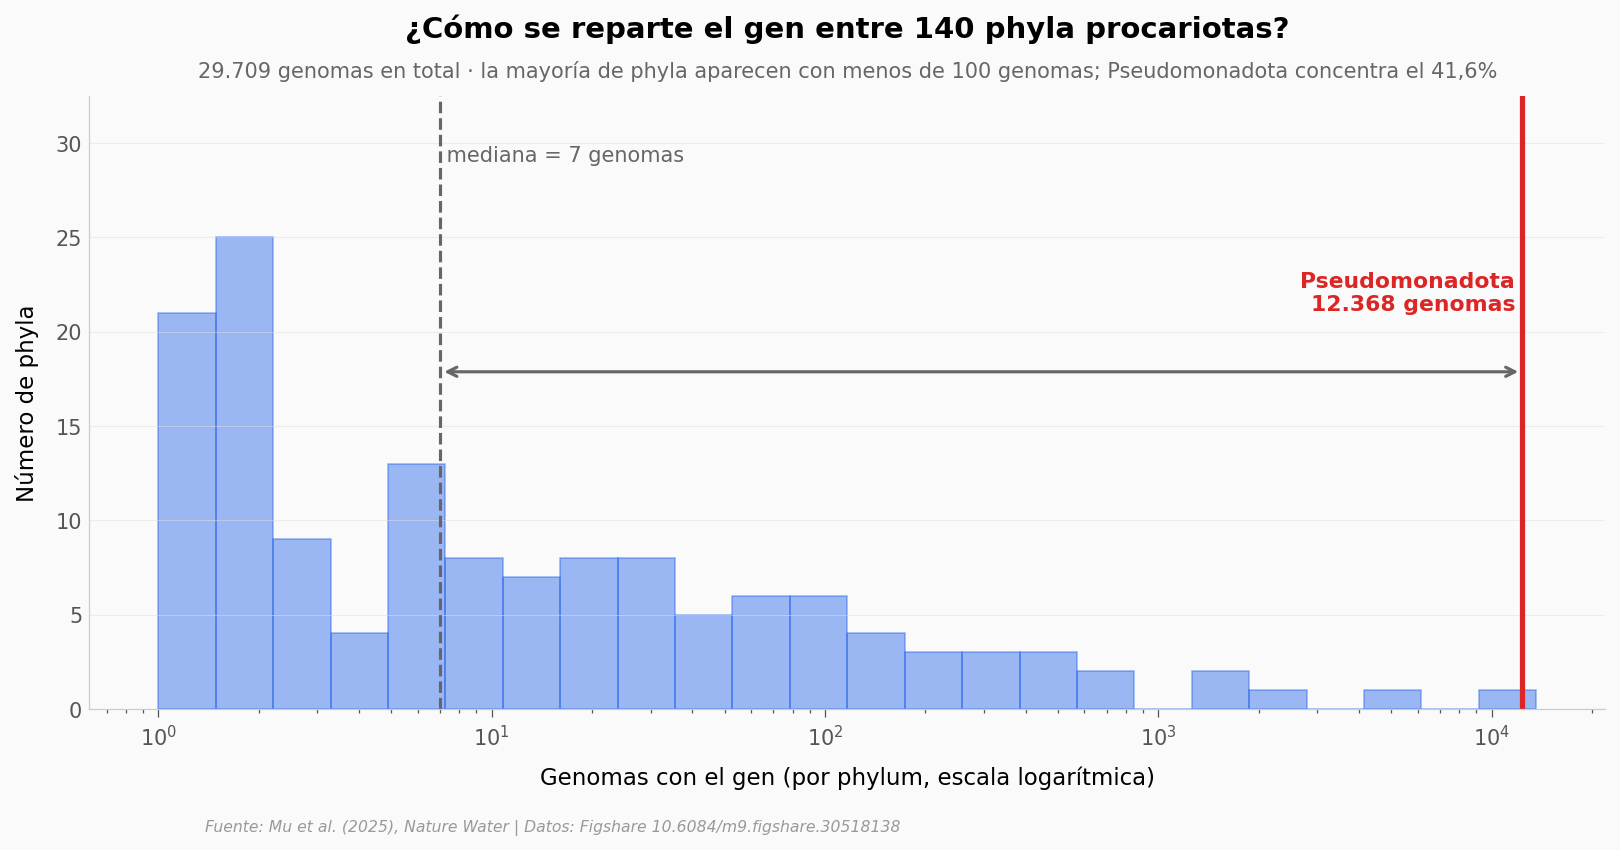

Total genomas procariotas con la lyase: 29.709
Phyla cubiertos: 140
Top phylum (Pseudomonadota): 12.368 | 41.6% del total
Mediana de genomas/phylum: 7

Culturables: 15.603 (52.5%)
No culturables: 14.106 (47.5%)


In [5]:
# Gráfica 4: Histograma del tamaño por phylum + posición del top phylum
fig, ax = plt.subplots(figsize=(11, 5.5))

n_por_phylum = proc_phylum['n_genomas'].values
top_phylum = proc_phylum.iloc[0]
mediana = np.median(n_por_phylum)

# Histograma log-scale por la cola larga
bins = np.logspace(0, np.log10(n_por_phylum.max() * 1.1), 25)
n_hist, bins_edges, patches = ax.hist(n_por_phylum, bins=bins, color=COLOR_DATOS, alpha=0.45,
                                       edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n_hist.max() * 1.30
ax.set_ylim(0, y_max)
ax.set_xscale('log')

ax.axvline(x=mediana, color='#666666', linewidth=1.5, linestyle='--')
ax.text(mediana, y_max * 0.92, f' mediana = {int(mediana)} genomas',
        fontsize=10, color='#666666', va='top')

ax.axvline(x=top_phylum['n_genomas'], color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('',
            xy=(top_phylum['n_genomas'], y_max * 0.55),
            xytext=(mediana, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(top_phylum['n_genomas'] * 0.95, y_max * 0.65,
        f'{top_phylum["phylum"]}\n{int(top_phylum["n_genomas"]):,}'.replace(',', '.') + ' genomas',
        fontsize=10.5, color=COLOR_ALERTA, fontweight='bold', ha='right')

ax.set_xlabel('Genomas con el gen (por phylum, escala logarítmica)', fontsize=11)
ax.set_ylabel('Número de phyla', fontsize=11)
ax.set_title('¿Cómo se reparte el gen entre 140 phyla procariotas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{int(proc_phylum["n_genomas"].sum()):,}'.replace(',', '.') + ' genomas en total · ' +
        'la mayoría de phyla aparecen con menos de 100 genomas; Pseudomonadota concentra el 41,6%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_procariotas_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

# Imprimir números para verificación
total_proc = int(proc_phylum['n_genomas'].sum())
n_phyla = len(proc_phylum)
print(f'Total genomas procariotas con la lyase: {total_proc:,}'.replace(',', '.'))
print(f'Phyla cubiertos: {n_phyla}')
print(f'Top phylum (Pseudomonadota): {int(top_phylum["n_genomas"]):,}'.replace(',', '.'), '|',
      f'{100 * top_phylum["n_genomas"] / total_proc:.1f}% del total')
print(f'Mediana de genomas/phylum: {int(mediana)}')

# Culturabilidad
cult = proc_cult.groupby('culturable')['n_genomas'].sum()
total_c = cult.sum()
print()
print(f'Culturables: {cult["YES"]:,}'.replace(',', '.'),
      f'({100*cult["YES"]/total_c:.1f}%)')
print(f'No culturables: {cult["NO"]:,}'.replace(',', '.'),
      f'({100*cult["NO"]/total_c:.1f}%)')

La distribución es la típica "cola larga": una mayoría de phyla con presencia testimonial, y unos pocos que concentran casi todo. **Pseudomonadota (~12.400 genomas, el 41,6%)** se lleva la parte mayor. Esta familia incluye muchas bacterias acuáticas comunes — *E. coli*, *Pseudomonas*, *Vibrio* — lo que añade una segunda ruta de reconversión potencial junto al fitoplancton.

Un dato adicional del propio set: alrededor del **52,5% de estos 29.709 genomas están en colecciones cultivables**. Importante para los próximos pasos experimentales — más de la mitad pueden, en principio, validarse en laboratorio.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| 18 especies de fitoplancton biotransforman NEA en lab | ✅ | El paper lo reporta como hallazgo experimental directo (n=18, diversidad filogenética representativa). |
| El gen aparece en 135 MAGs eukariotos repartidos en 11 océanos | ✅ | Datos del propio Figshare (Table S2). Detección genómica, no actividad medida. |
| Chromista + Plantae concentran ~87% de los MAGs | ✅ | 67 + 50 = 117 de 135 = 86,7%. Cálculo directo. |
| El gen está en 29.709 genomas procariotas | ✅ | Datos del Figshare (Table S1). |
| El fitoplancton oceánico está reconvirtiendo NEA *in situ* a gran escala | ⚠️ | El paper muestra transcripción del gen en metatranscriptomas, pero la actividad enzimática *in situ* (cuánta reconversión ocurre por mililitro de agua) no se cuantifica. La inferencia es razonable pero no directa. |
| Esto podría aumentar el riesgo ecológico de los progestogenos | ⚠️ | El abstract usa *"may exacerbate"*. Es plausible, pero la magnitud del riesgo neto depende de variables que el paper no mide: concentraciones reales de NEA en distintos cuerpos de agua, vida media del producto reconvertido, exposición a fauna. |

> **Limitaciones del análisis:**
> - Detección genética no equivale a función *in situ*. El gen puede estar presente sin transcribirse.
> - Los MAGs son ensamblajes — algunos genes detectados podrían ser falsos positivos por contaminación cruzada en el ensamblaje metagenómico.
> - El muestreo de Tara Oceans no es uniforme: cuencas con más muestras tienden a mostrar más MAGs.
> - El subset cultivable es una propiedad de las **colecciones humanas**, no del organismo — la cifra refleja qué hemos logrado cultivar, no qué es cultivable en principio.

## Ahora tú

Tres preguntas para empujar el dataset:

1. **¿Qué pasa si separas el conteo por hemisferio?** Pista: `oceano` tiene cadenas como `"Atlantic Ocean North"` vs `"Pacific Ocean South"`. ¿Cambia el balance Chromista/Plantae?
2. **¿La culturabilidad correlaciona con el número de genomas?** Para procariotas, los phyla "famosos" suelen estar sobrerrepresentados en colecciones cultivables — ¿se ve aquí?
3. **¿Cuántos phyla procariotas concentran el 80% del total?** Suma acumulada — el resultado dice qué tanto pesa la cola larga.

Modifica la celda siguiente para responder cualquiera.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿Cuántos phyla concentran el 80% del total?

orden_desc = proc_phylum.sort_values('n_genomas', ascending=False).copy()
orden_desc['cumulativo'] = orden_desc['n_genomas'].cumsum()
orden_desc['cumulativo_pct'] = 100 * orden_desc['cumulativo'] / orden_desc['n_genomas'].sum()

n_para_80 = (orden_desc['cumulativo_pct'] <= 80).sum() + 1
print(f'{n_para_80} phyla concentran el 80% de los {int(orden_desc["n_genomas"].sum()):,}'.replace(',', '.') + ' genomas')
print()
print(orden_desc.head(n_para_80)[['phylum', 'n_genomas', 'cumulativo_pct']].to_string(index=False))

7 phyla concentran el 80% de los 29.709 genomas

           phylum  n_genomas  cumulativo_pct
   Pseudomonadota      12368       41.630482
   Actinomycetota       5337       59.594736
      Bacillota_A       2122       66.737352
     Bacteroidota       1703       72.469622
        Bacillota       1411       77.219025
    Chloroflexota        747       79.733414
Verrucomicrobiota        578       81.678953


## Fuentes

**Paper**: [Chemoproteomics reveals global occurrence of a phytoplankton lyase capable of reconverting progestogens](https://doi.org/10.1038/s44221-026-00646-5)  
*Nature Water, 2025-11-03*

**Supplementary Material**: [Chemical Proteomics Revealed Global Occurrence of a Phytoplankton Lyase Capable of Reconverting the Progestogens (Tables S1 & S2)](https://doi.org/10.6084/m9.figshare.30518138)  
*Tablas S1 (29.709 genomas procariotas) y S2 (135 MAGs eukariotos) — Figshare*

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia:** CC BY 4.0 — usa, modifica, comparte citando.